# Machine Learning Research Notebook: Price Prediction Pipeline

## Executive Summary

This project leverages machine learning to forecast the auction sale prices of heavy equipment using a large-scale time-series dataset. The workflow includes extensive data preprocessing, categorical encoding, and hyperparameter optimization of a Random Forest Regressor to minimize Root Mean Squared Log Error (RMSLE). The final model provides a robust, data-driven approach to industrial asset valuation.

## Colab Notebook
This is the link to open the full interactive notebook in Google Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lotantamary/ML-Price-Prediction-Pipeline/blob/main/notebooks/research_and_eda.ipynb)
* The notebook includes data analysis, model architecture, and performance evaluation.*

### Framework

#### 1. Problem Definition

For this dataset, the problem we're trying to solve, or better, the question we're trying to answer is,

> How well can we predict the future sale price of a bulldozer, given its characteristics previous examples of how much similar bulldozers have been sold for?

#### 2. Data

Looking at the [dataset from Kaggle](https://www.kaggle.com/c/bluebook-for-bulldozers/data) we see that it contains historical sales data of bulldozers. Including things like, model type, size, sale date and more.

There are 3 datasets:

1. **Train.csv** - Historical bulldozer sales examples up to 2011 (close to 400,000 examples with 50+ different attributes, including `SalePrice` which is the **target variable**).
2. **Valid.csv** - Historical bulldozer sales examples from January 1 2012 to April 30 2012 (close to 12,000 examples with the same attributes as **Train.csv**).
3. **Test.csv** - Historical bulldozer sales examples from May 1 2012 to November 2012 (close to 12,000 examples but missing the `SalePrice` attribute, as this is what we'll be trying to predict).


#### 3. Evaluation

For this problem, [Kaggle has set the evaluation metric to being root mean squared log error (RMSLE)](https://www.kaggle.com/c/bluebook-for-bulldozers/overview/evaluation). As with many regression evaluations, the goal will be to get this value as low as possible

To see how well our model is doing, we'll calculate the RMSLE and then compare our results to others on the [Kaggle leaderboard](https://www.kaggle.com/c/bluebook-for-bulldozers/leaderboard).

#### 4. Features

**data dictionary**.

For this dataset, Kaggle provides a data dictionary which contains information about what each attribute of the dataset means.

For example:

| Variable Name | Description  | Variable Type |
|------|-----|-----|
| SalesID   | unique identifier of a particular sale of a machine at auction  | Independent  variable |
| MachineID  | identifier for a particular machine; machines may have multiple sales  | Independent  variable |
| ModelID | identifier for a unique machine model (i.e. fiModelDesc) | Independent  variable |
| datasource  | source of the sale record; some sources are more diligent about reporting attributes of the machine than others. Note that a particular datasource may report on multiple auctioneerIDs. | Independent  variable |
| auctioneerID  | identifier of a particular auctioneer, i.e. company that sold the machine at auction. Not the same as datasource.  | Independent  variable |
| YearMade  | year of manufacturer of the Machine  | Independent  variable |
| MachineHoursCurrentMeter | current usage of the machine in hours at time of sale (saledate); null or 0 means no hours have been reported for that sale | Independent  variable |
| UsageBand | value (low, medium, high) calculated comparing this particular Machine-Sale hours to average usage for the fiBaseModel; e.g. 'Low' means this machine has fewer hours given its lifespan relative to the average of fiBaseModel. | Independent  variable |
| Saledate   | time of sale | Independent  variable |
| fiModelDesc  | Description of a unique machine model (see ModelID); concatenation of fiBaseModel & fiSecondaryDesc & fiModelSeries & fiModelDescriptor  | Independent  variable |
| State | US State in which sale occurred | Independent  variable |
| Drive_System | machine configuration; typically describes whether 2 or 4 wheel drive  | Independent  variable |
| Enclosure  | machine configuration - does the machine have an enclosed cab or not | Independent  variable |
| Forks  | machine configuration - attachment used for lifting  | Independent  variable |
| Pad_Type | machine configuration - type of treads a crawler machine uses | Independent  variable |
| Ride_Control  | machine configuration - optional feature on loaders to make the ride smoother | Independent  variable |
| Transmission | machine configuration - describes type of transmission; typically automatic or manual | Independent  variable |
| ... | ... | ... |
| SalePrice | cost of sale in USD | Target/dependent variable |


In [ ]:
# Timestamp
import datetime

import datetime
print(f"Notebook last run (end-to-end): {datetime.datetime.now()}")

Notebook last run (end-to-end): 2026-01-21 14:31:10.976822


## 1. Importing the data and preparing it for modelling


In [ ]:
# Import data analysis tools
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Print the versions we're using
print(f"pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")

pandas version: 2.3.3
NumPy version: 2.3.5
matplotlib version: 3.10.7


In [ ]:
# Import the training and validation set
df = pd.read_csv(filepath_or_buffer="data/bluebook-for-bulldozers/TrainAndValid.csv", low_memory=False)

In [ ]:
# Get info about DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   object 
 9   saledate                  412698 non-null  object 
 10  fiModelDesc               412698 non-null  object 
 11  fiBaseModel               412698 non-null  object 
 12  fiSecondaryDesc           271971 non-null  object 
 13  fiModelSeries             58667 non-null   o

In [ ]:
df["saledate"][:10]

0    11/16/2006 0:00
1     3/26/2004 0:00
2     2/26/2004 0:00
3     5/19/2011 0:00
4     7/23/2009 0:00
5    12/18/2008 0:00
6     8/26/2004 0:00
7    11/17/2005 0:00
8     8/27/2009 0:00
9      8/9/2007 0:00
Name: saledate, dtype: object

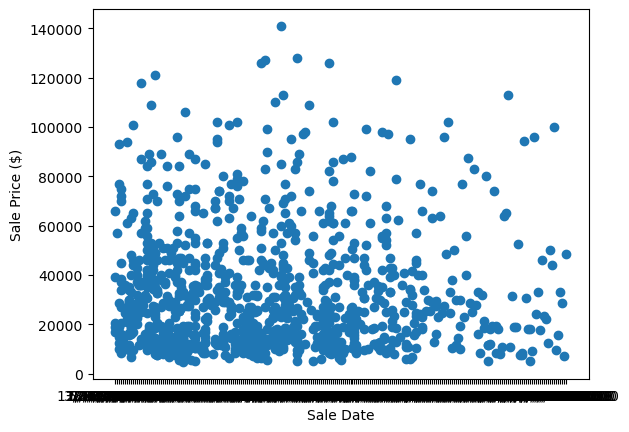

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x=df["saledate"][:1000], # visualize the first 1000 values
           y=df["SalePrice"][:1000])
ax.set_xlabel("Sale Date")
ax.set_ylabel("Sale Price ($)");

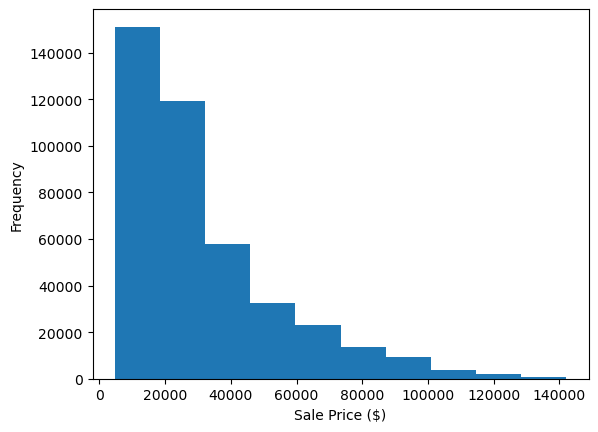

In [ ]:
# View SalePrice distribution
df.SalePrice.plot.hist(xlabel="Sale Price ($)");

### 1.1 Parsing dates

In [ ]:
df = pd.read_csv(filepath_or_buffer="data/bluebook-for-bulldozers/TrainAndValid.csv",
                 low_memory=False, # set low_memory=False to prevent mixed data types warning
                 parse_dates=["saledate"]) # can use the parse_dates parameter and specify which column to treat as a date column

# With parse_dates... check dtype of "saledate"
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   SalesID                   412698 non-null  int64         
 1   SalePrice                 412698 non-null  float64       
 2   MachineID                 412698 non-null  int64         
 3   ModelID                   412698 non-null  int64         
 4   datasource                412698 non-null  int64         
 5   auctioneerID              392562 non-null  float64       
 6   YearMade                  412698 non-null  int64         
 7   MachineHoursCurrentMeter  147504 non-null  float64       
 8   UsageBand                 73670 non-null   object        
 9   saledate                  412698 non-null  datetime64[ns]
 10  fiModelDesc               412698 non-null  object        
 11  fiBaseModel               412698 non-null  object        
 12  fi

In [ ]:
df["saledate"][:10]

0   2006-11-16
1   2004-03-26
2   2004-02-26
3   2011-05-19
4   2009-07-23
5   2008-12-18
6   2004-08-26
7   2005-11-17
8   2009-08-27
9   2007-08-09
Name: saledate, dtype: datetime64[ns]

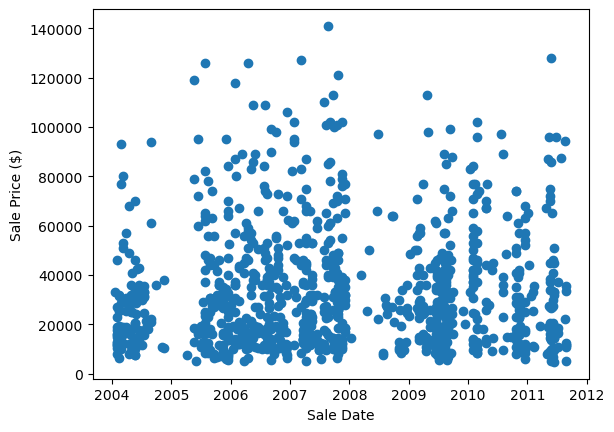

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x=df["saledate"][:1000], # visualize the first 1000 values
           y=df["SalePrice"][:1000])
ax.set_xlabel("Sale Date")
ax.set_ylabel("Sale Price ($)");

### 1.2 Sorting our DataFrame by saledate

In [ ]:
# Sort DataFrame in date order
df.sort_values(by=["saledate"], inplace=True, ascending=True)
df.saledate.head(10), df.saledate.tail(10)

(205615   1989-01-17
 274835   1989-01-31
 141296   1989-01-31
 212552   1989-01-31
 62755    1989-01-31
 54653    1989-01-31
 81383    1989-01-31
 204924   1989-01-31
 135376   1989-01-31
 113390   1989-01-31
 Name: saledate, dtype: datetime64[ns],
 409202   2012-04-28
 408976   2012-04-28
 411695   2012-04-28
 411319   2012-04-28
 408889   2012-04-28
 410879   2012-04-28
 412476   2012-04-28
 411927   2012-04-28
 407124   2012-04-28
 409203   2012-04-28
 Name: saledate, dtype: datetime64[ns])

### 1.3 Adding extra features to the DataFrame


In [ ]:
# Make a copy of the original DataFrame to perform edits on
df_tmp = df.copy()

In [ ]:
# Add datetime parameters for saledate
df_tmp["saleYear"] = df_tmp.saledate.dt.year
df_tmp["saleMonth"] = df_tmp.saledate.dt.month
df_tmp["saleDay"] = df_tmp.saledate.dt.day
df_tmp["saleDayofweek"] = df_tmp.saledate.dt.dayofweek
df_tmp["saleDayofyear"] = df_tmp.saledate.dt.dayofyear

# Drop original saledate column
df_tmp.drop("saledate", axis=1, inplace=True)

In [ ]:
# View newly created columns
df_tmp[["SalePrice", "saleYear", "saleMonth", "saleDay", "saleDayofweek", "saleDayofyear"]].head()

,SalePrice,saleYear,saleMonth,saleDay,saleDayofweek,saleDayofyear
205615,9500.0,1989,1,17,1,17
274835,14000.0,1989,1,31,1,31
141296,50000.0,1989,1,31,1,31
212552,16000.0,1989,1,31,1,31
62755,22000.0,1989,1,31,1,31


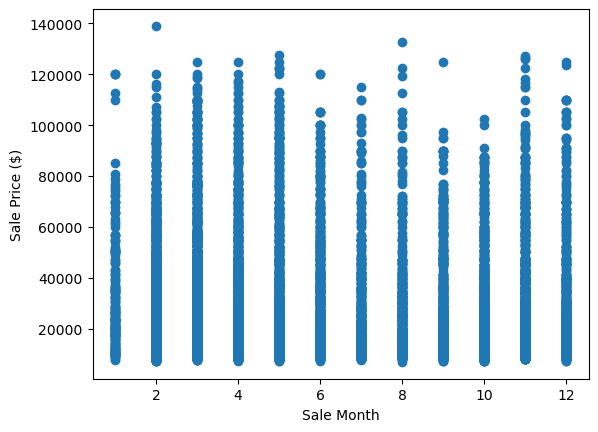

In [ ]:
# View 10,000 samples SalePrice against saleMonth
fig, ax = plt.subplots()
ax.scatter(x=df_tmp["saleMonth"][:10000], # visualize the first 10000 values
           y=df_tmp["SalePrice"][:10000])
ax.set_xlabel("Sale Month")
ax.set_ylabel("Sale Price ($)");

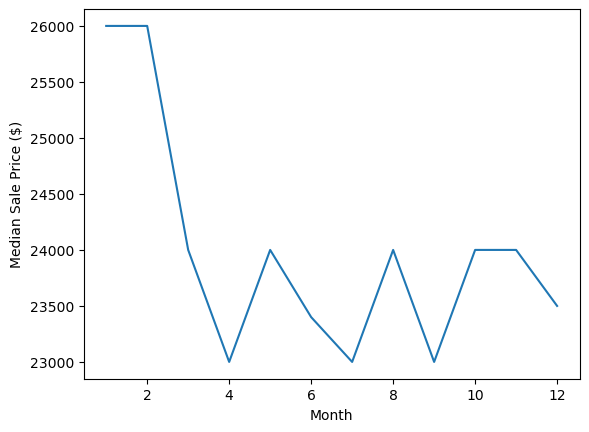

In [ ]:
# Group DataFrame by saleMonth and then find the median SalePrice
df_tmp.groupby(["saleMonth"])["SalePrice"].median().plot()
plt.xlabel("Month")
plt.ylabel("Median Sale Price ($)");

### 1.4 Inspect values of other columns

In [ ]:
# Check the different values of different columns
df_tmp.state.value_counts()[:10]

state
Florida        67320
Texas          53110
California     29761
Washington     16222
Georgia        14633
Maryland       13322
Mississippi    13240
Ohio           12369
Illinois       11540
Colorado       11529
Name: count, dtype: int64

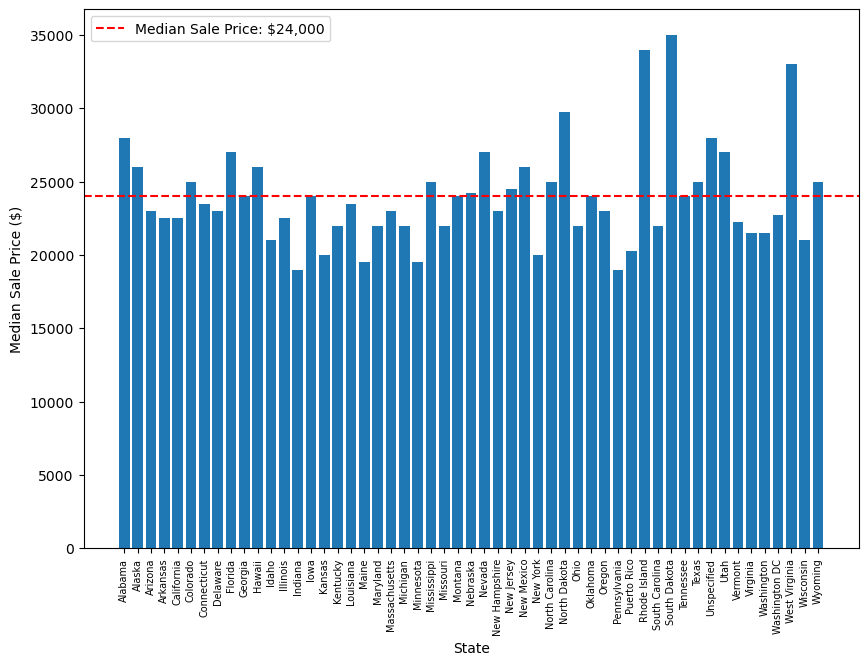

In [ ]:
# Group DataFrame by saleMonth and then find the median SalePrice per state as well as across the whole dataset
median_prices_by_state = df_tmp.groupby(["state"])["SalePrice"].median() # this will return a pandas Series rather than a DataFrame
median_sale_price = df_tmp["SalePrice"].median()

# Create a plot comparing median sale price per state to median sale price overall
plt.figure(figsize=(10, 7))
plt.bar(x=median_prices_by_state.index, # Because we're working with a Series, we can use the index (state names) as the x values
        height=median_prices_by_state.values)
plt.xlabel("State")
plt.ylabel("Median Sale Price ($)")
plt.xticks(rotation=90, fontsize=7);
plt.axhline(y=median_sale_price,
            color="red",
            linestyle="--",
            label=f"Median Sale Price: ${median_sale_price:,.0f}")
plt.legend();

## 2. Model driven data exploration


In [ ]:
# Check for missing values and different datatypes
from sklearn.ensemble import RandomForestRegressor
df_tmp.info();

<class 'pandas.core.frame.DataFrame'>
Index: 412698 entries, 205615 to 409203
Columns: 103 entries, SalesID to Steering_Controls_is_missing
dtypes: float64(3), int16(4), int32(5), int64(51), int8(40)
memory usage: 199.9 MB


In [ ]:
# Find missing values in the head of our DataFrame
df_tmp.head().isna()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,...,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,saleYear,saleMonth,saleDay,saleDayofweek,saleDayofyear
205615,False,False,False,False,False,False,False,True,True,False,...,False,False,False,True,True,False,False,False,False,False
274835,False,False,False,False,False,False,False,True,True,False,...,True,True,True,False,False,False,False,False,False,False
141296,False,False,False,False,False,False,False,True,True,False,...,False,False,False,True,True,False,False,False,False,False
212552,False,False,False,False,False,False,False,True,True,False,...,True,True,True,False,False,False,False,False,False,False
62755,False,False,False,False,False,False,False,True,True,False,...,False,False,False,True,True,False,False,False,False,False


In [ ]:
# Check for total missing values per column
df_tmp.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension             386715
Blade_Width         

### 2.1 Inspecting the datatypes in our DataFrame

In [ ]:
# Get the dtype of a given column
df_tmp["UsageBand"].dtype, df_tmp["UsageBand"].dtype.name

(dtype('O'), 'object')

In [ ]:
# Check whether a column is an object
pd.api.types.is_object_dtype(df_tmp["UsageBand"])

True

In [ ]:
# Check whether a column is a string
pd.api.types.is_string_dtype(df_tmp["state"])

True

In [ ]:
# Print column names and example content of columns which contain strings
for label, content in df_tmp.items():
    if pd.api.types.is_string_dtype(content):
        # Check datatype of target column
        column_datatype = df_tmp[label].dtype.name

        # Get random sample from column values
        example_value = content.sample(1).values

        # Infer random sample datatype
        example_value_dtype = pd.api.types.infer_dtype(example_value)
        print(f"Column name: {label} | Column dtype: {column_datatype} | Example value: {example_value} | Example value dtype: {example_value_dtype}")

Column name: fiModelDesc | Column dtype: object | Example value: ['8032ZTS'] | Example value dtype: string
Column name: fiBaseModel | Column dtype: object | Example value: ['644'] | Example value dtype: string
Column name: fiProductClassDesc | Column dtype: object | Example value: ['Track Type Tractor, Dozer - 20.0 to 75.0 Horsepower'] | Example value dtype: string
Column name: state | Column dtype: object | Example value: ['Connecticut'] | Example value dtype: string
Column name: ProductGroup | Column dtype: object | Example value: ['TEX'] | Example value dtype: string
Column name: ProductGroupDesc | Column dtype: object | Example value: ['Backhoe Loaders'] | Example value dtype: string


In [ ]:
# Start a count of how many object type columns there are
number_of_object_type_columns = 0

for label, content in df_tmp.items():
    # Check to see if column is of object type (this will include the string columns)
    if pd.api.types.is_object_dtype(content):
        # Check datatype of target column
        column_datatype = df_tmp[label].dtype.name

        # Get random sample from column values
        example_value = content.sample(1).values

        # Infer random sample datatype
        example_value_dtype = pd.api.types.infer_dtype(example_value)
        print(f"Column name: {label} | Column dtype: {column_datatype} | Example value: {example_value} | Example value dtype: {example_value_dtype}")

        number_of_object_type_columns += 1

print(f"\n[INFO] Total number of object type columns: {number_of_object_type_columns}")

Column name: UsageBand | Column dtype: object | Example value: [nan] | Example value dtype: empty
Column name: fiModelDesc | Column dtype: object | Example value: ['555E'] | Example value dtype: string
Column name: fiBaseModel | Column dtype: object | Example value: ['D4'] | Example value dtype: string
Column name: fiSecondaryDesc | Column dtype: object | Example value: [nan] | Example value dtype: empty
Column name: fiModelSeries | Column dtype: object | Example value: [nan] | Example value dtype: empty
Column name: fiModelDescriptor | Column dtype: object | Example value: [nan] | Example value dtype: empty
Column name: ProductSize | Column dtype: object | Example value: ['Mini'] | Example value dtype: string
Column name: fiProductClassDesc | Column dtype: object | Example value: ['Wheel Loader - 100.0 to 110.0 Horsepower'] | Example value dtype: string
Column name: state | Column dtype: object | Example value: ['Illinois'] | Example value dtype: string
Column name: ProductGroup | Col

### 2.2 Converting strings to categories with pandas

In pandas, one way to convert object/string values to numerical values is to convert them to categories or more specifically, the `pd.CategoricalDtype` datatype.

This datatype keeps the underlying data the same (e.g. doesn't change the string) but enables easy conversion to a numeric code using [`.cat.codes`](https://pandas.pydata.org/docs/reference/api/pandas.Series.cat.codes.html).

For example, the column `state` might have the values `'Alabama', 'Alaska', 'Arizona'...` and these could be mapped to numeric values `1, 2, 3...` respectively.

To see this in action, let's first convert the object datatype columns to `"category"` datatype.

We can do so by looping through the `.items()` of our DataFrame and reassigning each object datatype column using [`pandas.Series.astype(dtype="category")`](https://pandas.pydata.org/docs/reference/api/pandas.Series.astype.html).

In [ ]:
# This will turn all of the object columns into category values
for label, content in df_tmp.items():
    if pd.api.types.is_object_dtype(content):
        df_tmp[label] = df_tmp[label].astype("category")

In [ ]:
df_tmp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412698 entries, 205615 to 409203
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   SalesID                   412698 non-null  int64   
 1   SalePrice                 412698 non-null  float64 
 2   MachineID                 412698 non-null  int64   
 3   ModelID                   412698 non-null  int64   
 4   datasource                412698 non-null  int64   
 5   auctioneerID              392562 non-null  float64 
 6   YearMade                  412698 non-null  int64   
 7   MachineHoursCurrentMeter  147504 non-null  float64 
 8   UsageBand                 73670 non-null   category
 9   fiModelDesc               412698 non-null  category
 10  fiBaseModel               412698 non-null  category
 11  fiSecondaryDesc           271971 non-null  category
 12  fiModelSeries             58667 non-null   category
 13  fiModelDescriptor         748

In [ ]:
# Check the datatype of a single column
df_tmp.state.dtype

CategoricalDtype(categories=['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
                  'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Georgia',
                  'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas',
                  'Kentucky', 'Louisiana', 'Maine', 'Maryland',
                  'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi',
                  'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
                  'New Jersey', 'New Mexico', 'New York', 'North Carolina',
                  'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
                  'Puerto Rico', 'Rhode Island', 'South Carolina',
                  'South Dakota', 'Tennessee', 'Texas', 'Unspecified', 'Utah',
                  'Vermont', 'Virginia', 'Washington', 'Washington DC',
                  'West Virginia', 'Wisconsin', 'Wyoming'],
, ordered=False, categories_dtype=object)

In [ ]:
# Get the category names of a given column
df_tmp.state.cat.categories

Index(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
       'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
       'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
       'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
       'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
       'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
       'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon',
       'Pennsylvania', 'Puerto Rico', 'Rhode Island', 'South Carolina',
       'South Dakota', 'Tennessee', 'Texas', 'Unspecified', 'Utah', 'Vermont',
       'Virginia', 'Washington', 'Washington DC', 'West Virginia', 'Wisconsin',
       'Wyoming'],
      dtype='object')

In [ ]:
# Inspect the category codes
df_tmp.state.cat.codes

205615    43
274835     8
141296     8
212552     8
62755      8
          ..
410879     4
412476     4
411927     4
407124     4
409203     4
Length: 412698, dtype: int8

In [ ]:
# Get example string using category number
target_state_cat_number = 43
target_state_cat_value = df_tmp.state.cat.categories[target_state_cat_number]
print(f"[INFO] Target state category number {target_state_cat_number} maps to: {target_state_cat_value}")

[INFO] Target state category number 43 maps to: Texas


### 2.3 Finding and filling missing values

In [ ]:
# Check missing values
df_tmp.isna().sum().sort_values(ascending=False)[:20]

Blade_Width          386715
Engine_Horsepower    386715
Tip_Control          386715
Pushblock            386715
Blade_Extension      386715
Enclosure_Type       386715
Scarifier            386704
Hydraulics_Flow      367823
Grouser_Tracks       367823
Coupler_System       367724
fiModelSeries        354031
Steering_Controls    341176
Differential_Type    341134
UsageBand            339028
fiModelDescriptor    337882
Backhoe_Mounting     331986
Stick                331602
Turbocharged         331602
Pad_Type             331602
Blade_Type           330823
dtype: int64

### 2.4 Filling missing numerical values

In [ ]:
# Find numeric columns
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        # Check datatype of target column
        column_datatype = df_tmp[label].dtype.name

        # Get random sample from column values
        example_value = content.sample(1).values

        # Infer random sample datatype
        example_value_dtype = pd.api.types.infer_dtype(example_value)
        print(f"Column name: {label} | Column dtype: {column_datatype} | Example value: {example_value} | Example value dtype: {example_value_dtype}")

Column name: SalesID | Column dtype: int64 | Example value: [1453817] | Example value dtype: integer
Column name: SalePrice | Column dtype: float64 | Example value: [22000.] | Example value dtype: floating
Column name: MachineID | Column dtype: int64 | Example value: [1441657] | Example value dtype: integer
Column name: ModelID | Column dtype: int64 | Example value: [19325] | Example value dtype: integer
Column name: datasource | Column dtype: int64 | Example value: [149] | Example value dtype: integer
Column name: auctioneerID | Column dtype: float64 | Example value: [1.] | Example value dtype: floating
Column name: YearMade | Column dtype: int64 | Example value: [1987] | Example value dtype: integer
Column name: MachineHoursCurrentMeter | Column dtype: float64 | Example value: [nan] | Example value dtype: floating
Column name: saleYear | Column dtype: int32 | Example value: [2000] | Example value dtype: integer
Column name: saleMonth | Column dtype: int32 | Example value: [3] | Examp

In [ ]:
# Check for which numeric columns have null values
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            print(f"Column name: {label} | Has missing values: {True}")
        else:
            print(f"Column name: {label} | Has missing values: {False}")

Column name: SalesID | Has missing values: False
Column name: SalePrice | Has missing values: False
Column name: MachineID | Has missing values: False
Column name: ModelID | Has missing values: False
Column name: datasource | Has missing values: False
Column name: auctioneerID | Has missing values: True
Column name: YearMade | Has missing values: False
Column name: MachineHoursCurrentMeter | Has missing values: True
Column name: saleYear | Has missing values: False
Column name: saleMonth | Has missing values: False
Column name: saleDay | Has missing values: False
Column name: saleDayofweek | Has missing values: False
Column name: saleDayofyear | Has missing values: False


In [ ]:
# Fill missing numeric values with the median of the target column
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():

            # Add a binary column which tells if the data was missing our not
            df_tmp[label+"_is_missing"] = pd.isnull(content).astype(int) # this will add a 0 or 1 value to rows with missing values (e.g. 0 = not missing, 1 = missing)

            # Fill missing numeric values with median since it's more robust than the mean
            df_tmp[label] = content.fillna(content.median())

In [ ]:
# Show rows where MachineHoursCurrentMeter_is_missing == 1
df_tmp[df_tmp["MachineHoursCurrentMeter_is_missing"] == 1].sample(5)

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,...,Travel_Controls,Differential_Type,Steering_Controls,saleYear,saleMonth,saleDay,saleDayofweek,saleDayofyear,auctioneerID_is_missing,MachineHoursCurrentMeter_is_missing
144329,1512381,22000.0,436270,7001,132,2.0,1979,0.0,NaN,215,...,NaN,NaN,NaN,1995,4,1,5,91,0,1
265072,1801298,7250.0,1250347,9550,132,2.0,1996,0.0,NaN,753,...,NaN,NaN,NaN,2002,8,17,5,229,0,1
250035,1764269,52000.0,1325778,23618,132,1.0,2005,0.0,NaN,WA320-5L,...,NaN,Standard,Conventional,2009,5,5,1,125,0,1
177860,1609599,40000.0,1334569,4700,132,1.0,1997,0.0,NaN,544G,...,NaN,Standard,Conventional,2001,9,19,2,262,0,1
171805,1600342,18500.0,1497551,8247,132,99.0,1982,0.0,NaN,644,...,NaN,Standard,Conventional,1993,8,20,4,232,0,1


In [ ]:
# Check for which numeric columns have null values
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            print(f"Column name: {label} | Has missing values: {True}")
        else:
            print(f"Column name: {label} | Has missing values: {False}")

Column name: SalesID | Has missing values: False
Column name: SalePrice | Has missing values: False
Column name: MachineID | Has missing values: False
Column name: ModelID | Has missing values: False
Column name: datasource | Has missing values: False
Column name: auctioneerID | Has missing values: False
Column name: YearMade | Has missing values: False
Column name: MachineHoursCurrentMeter | Has missing values: False
Column name: saleYear | Has missing values: False
Column name: saleMonth | Has missing values: False
Column name: saleDay | Has missing values: False
Column name: saleDayofweek | Has missing values: False
Column name: saleDayofyear | Has missing values: False
Column name: auctioneerID_is_missing | Has missing values: False
Column name: MachineHoursCurrentMeter_is_missing | Has missing values: False


In [ ]:
# Check to see how many examples in the auctioneerID were missing
df_tmp.auctioneerID_is_missing.value_counts()

auctioneerID_is_missing
0    392562
1     20136
Name: count, dtype: int64

### 2.5 Filling missing categorical values with pandas

In [ ]:
# Check columns which aren't numeric
print(f"[INFO] Columns which are not numeric:")
for label, content in df_tmp.items():
    if not pd.api.types.is_numeric_dtype(content):
        print(f"Column name: {label} | Column dtype: {df_tmp[label].dtype.name}")

[INFO] Columns which are not numeric:
Column name: UsageBand | Column dtype: category
Column name: fiModelDesc | Column dtype: category
Column name: fiBaseModel | Column dtype: category
Column name: fiSecondaryDesc | Column dtype: category
Column name: fiModelSeries | Column dtype: category
Column name: fiModelDescriptor | Column dtype: category
Column name: ProductSize | Column dtype: category
Column name: fiProductClassDesc | Column dtype: category
Column name: state | Column dtype: category
Column name: ProductGroup | Column dtype: category
Column name: ProductGroupDesc | Column dtype: category
Column name: Drive_System | Column dtype: category
Column name: Enclosure | Column dtype: category
Column name: Forks | Column dtype: category
Column name: Pad_Type | Column dtype: category
Column name: Ride_Control | Column dtype: category
Column name: Stick | Column dtype: category
Column name: Transmission | Column dtype: category
Column name: Turbocharged | Column dtype: category
Column n

In [ ]:
# 1. Create a dictionary to store column to category values (e.g. we turn our category types into numbers but we keep a record so we can go back)
column_to_category_dict = {}

# 2. Turn categorical variables into numbers
for label, content in df_tmp.items():

    # 3. Check columns which *aren't* numeric
    if not pd.api.types.is_numeric_dtype(content):

        # 4. Add binary column to inidicate whether sample had missing value
        df_tmp[label+"_is_missing"] = pd.isnull(content).astype(int)

        # 5. Ensure content is categorical and get its category codes
        content_categories = pd.Categorical(content)
        content_category_codes = content_categories.codes + 1 # prevents -1 (the default for NaN values) from being used for missing values (we'll treat missing values as 0)

        # 6. Add column key to dictionary with code: category mapping per column
        column_to_category_dict[label] = dict(zip(content_category_codes, content_categories))

        # 7. Set the column to the numerical values (the category code value)
        df_tmp[label] = content_category_codes

In [ ]:
df_tmp.sample(5)

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,...,Undercarriage_Pad_Width_is_missing,Stick_Length_is_missing,Thumb_is_missing,Pattern_Changer_is_missing,Grouser_Type_is_missing,Backhoe_Mounting_is_missing,Blade_Type_is_missing,Travel_Controls_is_missing,Differential_Type_is_missing,Steering_Controls_is_missing
134520,1491872,33000.0,1130256,4107,132,99.0,1988,0.0,0,2178,...,1,1,1,1,1,0,0,0,1,1
237253,1738003,8750.0,1105908,529,132,9.0,1987,0.0,0,4037,...,0,0,0,0,0,1,1,1,1,1
291057,2209062,23000.0,1787982,3180,136,1.0,1000,0.0,0,1095,...,1,1,1,1,1,1,1,1,1,1
194193,1631621,29000.0,1102473,4794,132,3.0,1998,0.0,0,1317,...,1,1,1,1,1,1,1,1,1,1
31369,1263593,14000.0,1530916,22318,132,1.0,1982,0.0,0,1268,...,1,1,1,1,1,1,1,1,1,1


In [ ]:
# Check the UsageBand (measure of bulldozer usage)
for key, value in sorted(column_to_category_dict["UsageBand"].items()): # note: calling sorted() on dictionary.items() sorts the dictionary by keys
    print(f"{key} -> {value}")

0 -> nan
1 -> High
2 -> Low
3 -> Medium


In [ ]:
# Check the first 10 state column values
for key, value in sorted(column_to_category_dict["state"].items())[:10]:
    print(f"{key} -> {value}")

1 -> Alabama
2 -> Alaska
3 -> Arizona
4 -> Arkansas
5 -> California
6 -> Colorado
7 -> Connecticut
8 -> Delaware
9 -> Florida
10 -> Georgia


In [ ]:
# Check total number of missing values
total_missing_values = df_tmp.isna().sum().sum()

if total_missing_values == 0:
    print(f"[INFO] Total missing values: {total_missing_values} - good")
else:
    print(f"[INFO] Uh ohh... total missing values: {total_missing_values} - not good")

[INFO] Total missing values: 0 - good


## 3. Splitting data into the right train/validation sets


In [ ]:
# Import train samples (making sure to parse dates and then sort by them)
train_df = pd.read_csv(filepath_or_buffer="data/bluebook-for-bulldozers/Train.csv",
                       parse_dates=["saledate"],
                       low_memory=False).sort_values(by="saledate", ascending=True)

# Import validation samples (making sure to parse dates and then sort by them)
valid_df = pd.read_csv(filepath_or_buffer="data/bluebook-for-bulldozers/Valid.csv",
                       parse_dates=["saledate"])

# The ValidSolution.csv contains the SalePrice values for the samples in Valid.csv
valid_solution = pd.read_csv(filepath_or_buffer="data/bluebook-for-bulldozers/ValidSolution.csv")

# Map valid_solution to valid_df
valid_df["SalePrice"] = valid_df["SalesID"].map(valid_solution.set_index("SalesID")["SalePrice"])

# Make sure valid_df is sorted by saledate still
valid_df = valid_df.sort_values("saledate", ascending=True).reset_index(drop=True)

# How many samples are in each DataFrame?
print(f"[INFO] Number of samples in training DataFrame: {len(train_df)}")
print(f"[INFO] Number of samples in validation DataFrame: {len(valid_df)}")

[INFO] Number of samples in training DataFrame: 401125
[INFO] Number of samples in validation DataFrame: 11573


In [ ]:
# check the training DataFrame
train_df.sample(5)

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
219280,1687238,85000,1489238,15330,132,1.0,2006,4569.0,High,2009-02-06,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
197562,1635815,17500,1094593,4579,132,1.0,2002,NaN,NaN,2007-05-22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
239736,1742956,14500,1339956,530,132,2.0,1990,NaN,NaN,2000-03-30,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
274337,1818777,15000,1519946,9854,132,1.0,1000,NaN,NaN,2001-02-28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
224707,1708003,16750,1377699,5158,132,4.0,1988,NaN,NaN,1996-02-08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# chack validation DataFrame
valid_df.sample(5)

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,fiModelDesc,...,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,SalePrice
2589,4354265,2295050,2144,172,1,2007,4010.0,Medium,2012-02-12,SK210LC,...,None or Unspecified,Manual,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN,75000.0
8166,6262329,709315,3406,149,1,1988,NaN,NaN,2012-03-27,225B,...,"9' 6""",Hydraulic,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN,12000.0
3291,6299683,1681380,2147,149,1,1997,NaN,NaN,2012-02-13,SK220LC,...,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN,30000.0
8784,6271118,910453,13864,149,1,1994,NaN,NaN,2012-03-28,D6HIIXL,...,NaN,NaN,NaN,NaN,None or Unspecified,Semi U,None or Unspecified,NaN,NaN,55000.0
183,6264604,261655,23926,149,12,1995,NaN,NaN,2012-01-18,12HNA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76000.0


In [ ]:
# Make a function to add date columns
def add_datetime_features_to_df(df, date_column="saledate"):
    # Add datetime parameters for saledate
    df["saleYear"] = df[date_column].dt.year
    df["saleMonth"] = df[date_column].dt.month
    df["saleDay"] = df[date_column].dt.day
    df["saleDayofweek"] = df[date_column].dt.dayofweek
    df["saleDayofyear"] = df[date_column].dt.dayofyear

    # Drop original saledate column
    df.drop("saledate", axis=1, inplace=True)

    return df

train_df = add_datetime_features_to_df(df=train_df)
valid_df = add_datetime_features_to_df(df=valid_df)

In [ ]:
# Display the last 5 columns (the recently added datetime breakdowns)
train_df.iloc[:, -5:].sample(5)

,saleYear,saleMonth,saleDay,saleDayofweek,saleDayofyear
353111,2008,6,24,1,176
258102,2008,2,19,1,50
323891,2007,11,14,2,318
392404,2011,10,3,0,276
285713,2007,12,18,1,352


In [ ]:
# Split training data into features and labels
X_train = train_df.drop("SalePrice", axis=1)
y_train = train_df["SalePrice"]

# Split validation data into features and labels
X_valid = valid_df.drop("SalePrice", axis=1)
y_valid = valid_df["SalePrice"]

### 3.1 Encoding categorical features as numbers using Scikit-Learn

In [ ]:
# Define numerical and categorical features
numerical_features = [label for label, content in X_train.items() if pd.api.types.is_numeric_dtype(content)]
categorical_features = [label for label, content in X_train.items() if not pd.api.types.is_numeric_dtype(content)]

print(f"[INFO] Numeric features: {numerical_features}")
print(f"[INFO] Categorical features: {categorical_features[:10]}...")

[INFO] Numeric features: ['SalesID', 'MachineID', 'ModelID', 'datasource', 'auctioneerID', 'YearMade', 'MachineHoursCurrentMeter', 'saleYear', 'saleMonth', 'saleDay', 'saleDayofweek', 'saleDayofyear']
[INFO] Categorical features: ['UsageBand', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc', 'fiModelSeries', 'fiModelDescriptor', 'ProductSize', 'fiProductClassDesc', 'state', 'ProductGroup']...


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# 1. Create an ordinal encoder (turns category items into numeric representation)
ordinal_encoder = OrdinalEncoder(categories="auto",
                                 handle_unknown="use_encoded_value",
                                 unknown_value=np.nan,
                                 encoded_missing_value=np.nan) # treat unknown categories as np.nan (or None)

# 2. Fit and transform the categorical columns of X_train
X_train_preprocessed = X_train.copy() # make copies of the oringal DataFrames so we can keep the original values in tact and view them later
X_train_preprocessed[categorical_features] = ordinal_encoder.fit_transform(X_train_preprocessed[categorical_features].astype(str)) # OrdinalEncoder expects all values as the same type (e.g. string or numeric only)

# 3. Transform the categorical columns of X_valid
X_valid_preprocessed = X_valid.copy()
X_valid_preprocessed[categorical_features] = ordinal_encoder.transform(X_valid_preprocessed[categorical_features].astype(str)) # only use `transform` on the validation data

In [ ]:
X_train.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,saleYear,saleMonth,saleDay,saleDayofweek,saleDayofyear
205615,1646770,1126363,8434,132,18.0,1974,NaN,NaN,TD20,TD20,...,None or Unspecified,Straight,None or Unspecified,NaN,NaN,1989,1,17,1,17
92803,1404019,1169900,7110,132,99.0,1986,NaN,NaN,416,416,...,NaN,NaN,NaN,NaN,NaN,1989,1,31,1,31
98346,1415646,1262088,3357,132,99.0,1975,NaN,NaN,12G,12,...,NaN,NaN,NaN,NaN,NaN,1989,1,31,1,31
169297,1596358,1433229,8247,132,99.0,1978,NaN,NaN,644,644,...,NaN,NaN,NaN,Standard,Conventional,1989,1,31,1,31
274835,1821514,1194089,10150,132,99.0,1980,NaN,NaN,A66,A66,...,NaN,NaN,NaN,Standard,Conventional,1989,1,31,1,31


In [ ]:
X_train_preprocessed.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,saleYear,saleMonth,saleDay,saleDayofweek,saleDayofyear
205615,1646770,1126363,8434,132,18.0,1974,NaN,3.0,4536.0,1734.0,...,0.0,7.0,5.0,4.0,5.0,1989,1,17,1,17
92803,1404019,1169900,7110,132,99.0,1986,NaN,3.0,734.0,242.0,...,2.0,10.0,7.0,4.0,5.0,1989,1,31,1,31
98346,1415646,1262088,3357,132,99.0,1975,NaN,3.0,81.0,18.0,...,2.0,10.0,7.0,4.0,5.0,1989,1,31,1,31
169297,1596358,1433229,8247,132,99.0,1978,NaN,3.0,1157.0,348.0,...,2.0,10.0,7.0,3.0,1.0,1989,1,31,1,31
274835,1821514,1194089,10150,132,99.0,1980,NaN,3.0,1799.0,556.0,...,2.0,10.0,7.0,3.0,1.0,1989,1,31,1,31


In [ ]:
X_train[categorical_features].isna().sum().sort_values(ascending=False)[:10]

Engine_Horsepower    375906
Blade_Extension      375906
Tip_Control          375906
Pushblock            375906
Enclosure_Type       375906
Blade_Width          375906
Scarifier            375895
Hydraulics_Flow      357763
Grouser_Tracks       357763
Coupler_System       357667
dtype: int64

In [ ]:
X_train_preprocessed[categorical_features].isna().sum().sort_values(ascending=False)[:10]

UsageBand         0
fiModelDesc       0
Pushblock         0
Ripper            0
Scarifier         0
Tip_Control       0
Tire_Size         0
Coupler           0
Coupler_System    0
Grouser_Tracks    0
dtype: int64

In [ ]:
# inspect the first three categories
ordinal_encoder.categories_[:3]

[array(['High', 'Low', 'Medium', 'nan'], dtype=object),
 array(['100C', '104', '1066', ..., 'ZX800LC', 'ZX80LCK', 'ZX850H'],
       shape=(4999,), dtype=object),
 array(['10', '100', '104', ..., 'ZX80', 'ZX800', 'ZX850'],
       shape=(1950,), dtype=object)]

In [ ]:
# Create a dictionary of dictionaries mapping column names and their variables to their numerical encoding
column_to_category_mapping = {}

for column_name, category_values in zip(categorical_features, ordinal_encoder.categories_):
    int_to_category = {i: category for i, category in enumerate(category_values)}
    column_to_category_mapping[column_name] = int_to_category

# Inspect an example column name to category mapping
column_to_category_mapping["UsageBand"]

{0: 'High', 1: 'Low', 2: 'Medium', 3: 'nan'}

In [ ]:
# Create a copy of the preprocessed DataFrame
X_train_unprocessed = X_train_preprocessed[categorical_features].copy()

# This will return an array of the original untransformed data
X_train_unprocessed = ordinal_encoder.inverse_transform(X_train_unprocessed)

# Turn back into a DataFrame for viewing pleasure
X_train_unprocessed_df = pd.DataFrame(X_train_unprocessed, columns=categorical_features)

# Check out a sample
X_train_unprocessed_df.sample(5)

,UsageBand,fiModelDesc,fiBaseModel,fiSecondaryDesc,fiModelSeries,fiModelDescriptor,ProductSize,fiProductClassDesc,state,ProductGroup,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
102821,nan,966D,966,D,nan,nan,Medium,Wheel Loader - 175.0 to 200.0 Horsepower,New York,WL,...,nan,nan,nan,nan,nan,nan,nan,nan,Standard,Conventional
230583,nan,17NE,17,NE,nan,nan,Mini,"Hydraulic Excavator, Track - 0.0 to 2.0 Metric...",Illinois,TEX,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,nan,nan,nan,nan,nan
28175,nan,580K,580,K,nan,nan,nan,Backhoe Loader - 14.0 to 15.0 Ft Standard Digg...,New Jersey,BL,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
250834,nan,863G,863,G,nan,nan,nan,Skid Steer Loader - 1751.0 to 2201.0 Lb Operat...,Florida,SSL,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
239902,High,325CL,325,C,nan,L,Large / Medium,"Hydraulic Excavator, Track - 28.0 to 33.0 Metr...",Texas,TEX,...,None or Unspecified,None or Unspecified,None or Unspecified,Yes,Double,nan,nan,nan,nan,nan


### 3.2 Fitting a model to the preprocessed training data

In [ ]:
%%time

# Instantiate a Random Forest Regression model
model = RandomForestRegressor(n_jobs=-1)

# Fit the model to the preprocessed training data
model.fit(X=X_train_preprocessed,
          y=y_train)

CPU times: total: 12min 8s
Wall time: 5min 53s


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
%%time

# Check model performance on the validation set
model.score(X=X_valid_preprocessed,
            y=y_valid)

CPU times: total: 1.05 s
Wall time: 277 ms


0.8698396905356162

In [ ]:
%%time

# Check model performance on the training set
model.score(X=X_train_preprocessed,
            y=y_train)

CPU times: total: 30 s
Wall time: 16.7 s


0.987297833697788

## 4. Building an evaluation function

According to Kaggle for the Bluebook for Bulldozers competition, [the evaluation function](https://www.kaggle.com/c/bluebook-for-bulldozers/overview/evaluation) they use is root mean squared log error (RMSLE).

$$ \text{RMSLE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left( \log(1 + \hat{y}_i) - \log(1 + y_i) \right)^2} $$

Where:

* $ \hat{y}_i $ is the predicted value,  
* $ y_i $ is the actual value,  
* $ n $ is the number of observations.

Contrast this with mean absolute error (MAE).

$$ \text{MAE} = \frac{1}{n} \sum_{i=1}^{n} \left| \hat{y}_i - y_i \right| $$

With RMSLE, the relative error is more meaningful than the absolute error.

In [ ]:
# Create evaluation function (the competition uses Root Mean Square Log Error)
from sklearn.metrics import mean_absolute_error, root_mean_squared_log_error

# Create function to evaluate our model
def show_scores(model,
                train_features=X_train_preprocessed,
                train_labels=y_train,
                valid_features=X_valid_preprocessed,
                valid_labels=y_valid):

    # Make predictions on train and validation features
    train_preds = model.predict(X=train_features)
    val_preds = model.predict(X=valid_features)

    # Create a scores dictionary of different evaluation metrics
    scores = {"Training MAE": mean_absolute_error(y_true=train_labels,
                                                  y_pred=train_preds),
              "Valid MAE": mean_absolute_error(y_true=valid_labels,
                                               y_pred=val_preds),
              "Training RMSLE": root_mean_squared_log_error(y_true=train_labels,
                                                            y_pred=train_preds),
              "Valid RMSLE": root_mean_squared_log_error(y_true=valid_labels,
                                                         y_pred=val_preds),
              "Training R^2": model.score(X=train_features,
                                          y=train_labels),
              "Valid R^2": model.score(X=valid_features,
                                       y=valid_labels)}
    return scores

In [ ]:
# Try our model scoring function out
model_scores = show_scores(model=model)
model_scores

{'Training MAE': 1595.4399001110964,
 'Valid MAE': 6173.854751864973,
 'Training RMSLE': 0.08540347165443454,
 'Valid RMSLE': 0.25854386676499574,
 'Training R^2': 0.987297833697788,
 'Valid R^2': 0.8698396905356162}

## 5. Tuning our model's hyperparameters

### 5.1 Making modelling experiments faster (to speed up hyperparameter tuning)

In [ ]:
%%time

# Change max samples in RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, # this is the default
                              n_jobs=-1,
                              max_samples=10000) # each estimator sees max_samples (the default is to see all available samples)

# Cutting down the max number of samples each tree can see improves training time
model.fit(X_train_preprocessed,
          y_train)

CPU times: total: 28.8 s
Wall time: 18.5 s


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Get evaluation metrics from reduced sample model
base_model_scores = show_scores(model=model)
base_model_scores

{'Training MAE': 5605.5175337862265,
 'Valid MAE': 7172.325888706471,
 'Training RMSLE': 0.2606932788733334,
 'Valid RMSLE': 0.29468711821797955,
 'Training R^2': 0.858324438988901,
 'Valid R^2': 0.8305221543119177}

### 5.2 Hyperparameter tuning with RandomizedSearchCV

In [ ]:
%%time

from sklearn.model_selection import RandomizedSearchCV

# 1. Define a dictionary with different values for RandomForestRegressor hyperparameters
# documatation for potential different values - https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html
rf_grid = {"n_estimators": np.arange(10, 200, 10),
           "max_depth": [None, 10, 20],
           "min_samples_split": np.arange(2, 10, 1), # min_samples_split must be an int in the range [2, inf) or a float in the range (0.0, 1.0]
           "min_samples_leaf": np.arange(1, 10, 1),
           "max_features": [0.5, 1.0, "sqrt"], # Note: "max_features='auto'" is equivalent to "max_features=1.0", as of Scikit-Learn version 1.1
           "max_samples": [10000]}

# 2. Setup instance of RandomizedSearchCV to explore different parameters
rs_model = RandomizedSearchCV(estimator=RandomForestRegressor(), # can pass new model instance directly, all settings will be taken from the rf_grid
                              param_distributions=rf_grid,
                              n_iter=20,
                            #   scoring="neg_root_mean_squared_log_error", # want to optimize for RMSLE, though sometimes optimizing for the default metric (R^2) can lead to just as good results all round
                              cv=3,
                              verbose=3) # control how much output gets produced, higher number = more output

# 3. Fit the model using a series of different hyperparameter values
rs_model.fit(X=X_train_preprocessed,
             y=y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV 1/3] END max_depth=None, max_features=1.0, max_samples=10000, min_samples_leaf=3, min_samples_split=9, n_estimators=70;, score=0.540 total time=  16.8s
[CV 2/3] END max_depth=None, max_features=1.0, max_samples=10000, min_samples_leaf=3, min_samples_split=9, n_estimators=70;, score=0.756 total time=  16.4s
[CV 3/3] END max_depth=None, max_features=1.0, max_samples=10000, min_samples_leaf=3, min_samples_split=9, n_estimators=70;, score=0.614 total time=  13.5s
[CV 1/3] END max_depth=None, max_features=0.5, max_samples=10000, min_samples_leaf=2, min_samples_split=9, n_estimators=140;, score=0.546 total time=  17.3s
[CV 2/3] END max_depth=None, max_features=0.5, max_samples=10000, min_samples_leaf=2, min_samples_split=9, n_estimators=140;, score=0.764 total time=  17.7s
[CV 3/3] END max_depth=None, max_features=0.5, max_samples=10000, min_samples_leaf=2, min_samples_split=9, n_estimators=140;, score=0.638 total time=  17.6s


,estimator,RandomForestRegressor()
,param_distributions,"{'max_depth': [None, 10, ...], 'max_features': [0.5, 1.0, ...], 'max_samples': [10000], 'min_samples_leaf': array([1, 2, ..., 6, 7, 8, 9]), ...}"
,n_iter,20
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,3
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [ ]:
# Find the best parameters from RandomizedSearchCV
rs_model.best_params_

{'n_estimators': np.int64(140),
 'min_samples_split': np.int64(9),
 'min_samples_leaf': np.int64(2),
 'max_samples': 10000,
 'max_features': 0.5,
 'max_depth': None}

In [ ]:
# Evaluate the RandomizedSearch model
rs_model_scores = show_scores(rs_model)
rs_model_scores

{'Training MAE': 5874.858907065184,
 'Valid MAE': 7298.309105782545,
 'Training RMSLE': 0.2696793423633016,
 'Valid RMSLE': 0.2996004753534134,
 'Training R^2': 0.8457215087075631,
 'Valid R^2': 0.8263754521827389}

### 5.3 Training a model with the best hyperparameters

In [ ]:
%%time

# Create a model with best found hyperparameters
ideal_model = RandomForestRegressor(n_estimators=90,
                                    max_depth=None,
                                    min_samples_leaf=1,
                                    min_samples_split=5,
                                    max_features=0.5,
                                    n_jobs=-1,
                                    max_samples=None)

# Fit a model to the preprocessed data
ideal_model.fit(X=X_train_preprocessed,
                y=y_train)

CPU times: total: 5min 22s
Wall time: 2min 39s


,n_estimators,90
,criterion,'squared_error'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
%%time

# Evaluate ideal model
ideal_model_scores = show_scores(model=ideal_model)
ideal_model_scores

CPU times: total: 41.4 s
Wall time: 22.9 s


{'Training MAE': 1955.1082355443443,
 'Valid MAE': 5973.694543652219,
 'Training RMSLE': 0.10213104387215227,
 'Valid RMSLE': 0.24687440012899448,
 'Training R^2': 0.9810355828662707,
 'Valid R^2': 0.8808810788546837}

In [ ]:
%%time

# Halve the number of estimators
fast_model = RandomForestRegressor(n_estimators=45,
                                   max_depth=None,
                                   min_samples_leaf=1,
                                   min_samples_split=5,
                                   max_features=0.5,
                                   n_jobs=-1,
                                   max_samples=None)

# Fit the faster model to the data
fast_model.fit(X=X_train_preprocessed,
               y=y_train)

CPU times: total: 2min 34s
Wall time: 1min 4s


,n_estimators,45
,criterion,'squared_error'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
%%time

# Get results from the fast model
fast_model_scores = show_scores(model=fast_model)
fast_model_scores

CPU times: total: 22.9 s
Wall time: 13.9 s


{'Training MAE': 1987.5659786421932,
 'Valid MAE': 5983.151102426926,
 'Training RMSLE': 0.1037314776123719,
 'Valid RMSLE': 0.24818861193825226,
 'Training R^2': 0.9803072506673346,
 'Valid R^2': 0.8806817003604104}

### 5.4 Comparing model's scores

In [ ]:
# Add names of models to dictionaries
base_model_scores["model_name"] = "default_model"
rs_model_scores["model_name"] = "random_search_model"
ideal_model_scores["model_name"] = "ideal_model"
fast_model_scores["model_name"] = "fast_model"

# Turn all model score dictionaries into a list
all_model_scores = [base_model_scores,
                    rs_model_scores,
                    ideal_model_scores,
                    fast_model_scores]

# Create DataFrame and sort model scores by validation RMSLE
model_comparison_df = pd.DataFrame(all_model_scores).sort_values(by="Valid RMSLE", ascending=False)
model_comparison_df.head()

,Training MAE,Valid MAE,Training RMSLE,Valid RMSLE,Training R^2,Valid R^2,model_name
1,5874.858907,7298.309106,0.269679,0.299600,0.845722,0.826375,random_search_model
0,5605.517534,7172.325889,0.260693,0.294687,0.858324,0.830522,default_model
3,1987.565979,5983.151102,0.103731,0.248189,0.980307,0.880682,fast_model
2,1955.108236,5973.694544,0.102131,0.246874,0.981036,0.880881,ideal_model


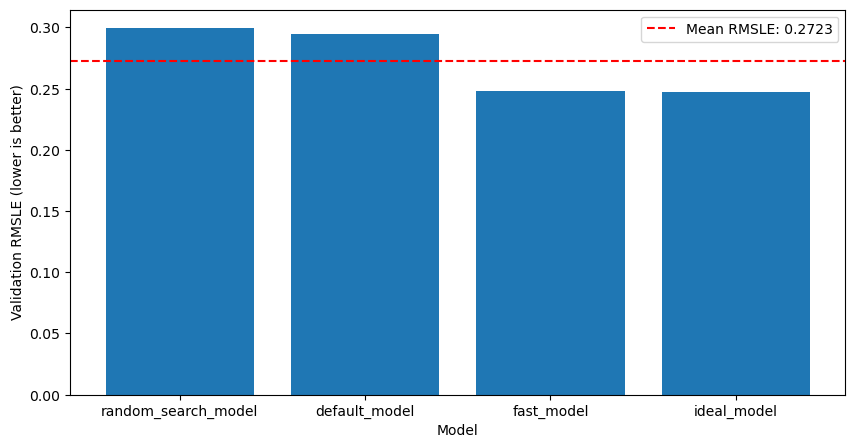

In [ ]:
# Get mean RSMLE score of all models
mean_rsmle_score = model_comparison_df["Valid RMSLE"].mean()

# Plot validation RMSLE against each other
plt.figure(figsize=(10, 5))
plt.bar(x=model_comparison_df["model_name"],
        height=model_comparison_df["Valid RMSLE"].values)
plt.xlabel("Model")
plt.ylabel("Validation RMSLE (lower is better)")
plt.xticks(rotation=0, fontsize=10);
plt.axhline(y=mean_rsmle_score,
            color="red",
            linestyle="--",
            label=f"Mean RMSLE: {mean_rsmle_score:.4f}")
plt.legend();

## 6. Saving the best model to file

In [ ]:
import joblib

bulldozer_price_prediction_model_name = "randomforest_regressor_best_RMSLE.pkl"

# Save model to file
joblib.dump(value=ideal_model,
            filename=bulldozer_price_prediction_model_name)

['randomforest_regressor_best_RMSLE.pkl']

In [ ]:
# Load the best model
best_model = joblib.load(filename=bulldozer_price_prediction_model_name)
best_model

,n_estimators,90
,criterion,'squared_error'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Confirm that the model works
best_model_scores = show_scores(model=best_model)
best_model_scores

{'Training MAE': 1955.1082355443443,
 'Valid MAE': 5973.694543652217,
 'Training RMSLE': 0.10213104387215227,
 'Valid RMSLE': 0.24687440012899448,
 'Training R^2': 0.9810355828662707,
 'Valid R^2': 0.8808810788546837}

## 7. Making predictions on test data

In [ ]:
# Load the test data
test_df = pd.read_csv(filepath_or_buffer="data/bluebook-for-bulldozers/Test.csv",
                      parse_dates=["saledate"])
test_df.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,fiModelDesc,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1227829,1006309,3168,121,3,1999,3688.0,Low,2012-05-03,580G,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1227844,1022817,7271,121,3,1000,28555.0,High,2012-05-10,936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1227847,1031560,22805,121,3,2004,6038.0,Medium,2012-05-10,EC210BLC,...,None or Unspecified,"9' 6""",Manual,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
3,1227848,56204,1269,121,3,2006,8940.0,High,2012-05-10,330CL,...,None or Unspecified,None or Unspecified,Manual,Yes,Triple,NaN,NaN,NaN,NaN,NaN
4,1227863,1053887,22312,121,3,2005,2286.0,Low,2012-05-10,650K,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,PAT,None or Unspecified,NaN,NaN


### 7.1 Preprocessing the test data (to be in the same format as the training data)

In [ ]:
# Make a function to add date columns
def add_datetime_features_to_df(df, date_column="saledate"):
    # Add datetime parameters for saledate
    df["saleYear"] = df[date_column].dt.year
    df["saleMonth"] = df[date_column].dt.month
    df["saleDay"] = df[date_column].dt.day
    df["saleDayofweek"] = df[date_column].dt.dayofweek
    df["saleDayofyear"] = df[date_column].dt.dayofyear

    # Drop original saledate column
    df.drop("saledate", axis=1, inplace=True)

    return df

# Preprocess test_df to have same columns as train_df (add the datetime features)
test_df = add_datetime_features_to_df(df=test_df)
test_df.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,saleYear,saleMonth,saleDay,saleDayofweek,saleDayofyear
0,1227829,1006309,3168,121,3,1999,3688.0,Low,580G,580,...,NaN,NaN,NaN,NaN,NaN,2012,5,3,3,124
1,1227844,1022817,7271,121,3,1000,28555.0,High,936,936,...,NaN,NaN,NaN,Standard,Conventional,2012,5,10,3,131
2,1227847,1031560,22805,121,3,2004,6038.0,Medium,EC210BLC,EC210,...,NaN,NaN,NaN,NaN,NaN,2012,5,10,3,131
3,1227848,56204,1269,121,3,2006,8940.0,High,330CL,330,...,NaN,NaN,NaN,NaN,NaN,2012,5,10,3,131
4,1227863,1053887,22312,121,3,2005,2286.0,Low,650K,650,...,None or Unspecified,PAT,None or Unspecified,NaN,NaN,2012,5,10,3,131


In [ ]:
# Create a copy of the test DataFrame to keep the original intact
test_df_preprocessed = test_df.copy()

# Transform the categorical features of the test DataFrame into numbers
test_df_preprocessed[categorical_features] = ordinal_encoder.transform(test_df_preprocessed[categorical_features].astype(str))
test_df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12457 entries, 0 to 12456
Data columns (total 56 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   SalesID                   12457 non-null  int64  
 1   MachineID                 12457 non-null  int64  
 2   ModelID                   12457 non-null  int64  
 3   datasource                12457 non-null  int64  
 4   auctioneerID              12457 non-null  int64  
 5   YearMade                  12457 non-null  int64  
 6   MachineHoursCurrentMeter  2129 non-null   float64
 7   UsageBand                 12457 non-null  float64
 8   fiModelDesc               12349 non-null  float64
 9   fiBaseModel               12431 non-null  float64
 10  fiSecondaryDesc           12449 non-null  float64
 11  fiModelSeries             12456 non-null  float64
 12  fiModelDescriptor         12452 non-null  float64
 13  ProductSize               12457 non-null  float64
 14  fiProd

In [ ]:
# Make predictions on the preprocessed test data
test_preds = best_model.predict(test_df_preprocessed)

In [ ]:
# Check the first 10 test predictions
test_preds[:10]

array([15231.2659612 , 32459.23500882, 49067.39638448, 97793.58686067,
       27794.0542328 , 29822.17312009, 26397.25697451, 19892.77336861,
       18697.03042328, 33483.60449735])

In [ ]:
# Create DataFrame compatible with Kaggle submission requirements
pred_df = pd.DataFrame()
pred_df["SalesID"] = test_df["SalesID"]
pred_df["SalePrice"] = test_preds
pred_df.sample(5)

,SalesID,SalePrice
12304,6640098,78165.906085
314,1228872,58784.012346
3252,6262267,84840.488316
2978,6259178,30422.610229
8840,6446430,12432.459436


In [ ]:
# Export test dataset predictions to CSV
pred_df.to_csv("data/bluebook-for-bulldozers/predictions.csv",
               index=False)

## 8. Making a prediction on a custom sample

In [ ]:
# Get example from test_df
test_df_preprocessed_sample = test_df_preprocessed.sample(n=1, random_state=42)

# Turn back into original format
test_df_unpreprocessed_sample = test_df_preprocessed_sample.copy()
test_df_unpreprocessed_sample[categorical_features] = ordinal_encoder.inverse_transform(test_df_unpreprocessed_sample[categorical_features])
test_df_unpreprocessed_sample.to_dict(orient="records")

[{'SalesID': 1229148,
  'MachineID': 1042578,
  'ModelID': 9579,
  'datasource': 121,
  'auctioneerID': 3,
  'YearMade': 2004,
  'MachineHoursCurrentMeter': 3290.0,
  'UsageBand': 'Medium',
  'fiModelDesc': 'S250',
  'fiBaseModel': 'S250',
  'fiSecondaryDesc': 'nan',
  'fiModelSeries': 'nan',
  'fiModelDescriptor': 'nan',
  'ProductSize': 'nan',
  'fiProductClassDesc': 'Skid Steer Loader - 2201.0 to 2701.0 Lb Operating Capacity',
  'state': 'Missouri',
  'ProductGroup': 'SSL',
  'ProductGroupDesc': 'Skid Steer Loaders',
  'Drive_System': 'nan',
  'Enclosure': 'EROPS',
  'Forks': 'None or Unspecified',
  'Pad_Type': 'nan',
  'Ride_Control': 'nan',
  'Stick': 'nan',
  'Transmission': 'nan',
  'Turbocharged': 'nan',
  'Blade_Extension': 'nan',
  'Blade_Width': 'nan',
  'Enclosure_Type': 'nan',
  'Engine_Horsepower': 'nan',
  'Hydraulics': 'Auxiliary',
  'Pushblock': 'nan',
  'Ripper': 'nan',
  'Scarifier': 'nan',
  'Tip_Control': 'nan',
  'Tire_Size': 'nan',
  'Coupler': 'Hydraulic',
  'C

In [ ]:
# Make a prediction on the preprocessed test sample
best_model.predict(test_df_preprocessed_sample)

array([13782.18915344])

In [ ]:
# Create a dictionary of features and values from an internet-based bulldozer advertisement
# link: https://www.purplewave.com/auction/240606/item/EK8504/2004-Caterpillar-D6R_XL-Crawlers-Crawler_Dozer-Missouri (note: this link is/was valid as of October 2024 but may be invalid in the future)
custom_sample = {
  "SalesID": np.nan,
  "MachineID": 8504,
  "ModelID": np.nan,
  "datasource": np.nan,
  "auctioneerID": np.nan,
  "YearMade": 2004,
  "MachineHoursCurrentMeter": 11770.0,
  "UsageBand": "High",
  "fiModelDesc": "D6RXL",
  "fiBaseModel": "D6",
  "fiSecondaryDesc": "XL",
  "fiModelSeries": np.nan,
  "fiModelDescriptor": np.nan,
  "ProductSize": "Medium",
  "fiProductClassDesc": "Track Type Tractor, Dozer - 130.0 to 160.0 Horsepower",
  "state": "Missouri",
  "ProductGroup": "TTT",
  "ProductGroupDesc": "Track Type Tractors",
  "Drive_System": "No",
  "Enclosure": "EROPS",
  "Forks": "None or Unspecified",
  "Pad_Type": "Grouser",
  "Ride_Control": "None or Unspecified",
  "Stick": "nan",
  "Transmission": "Powershift",
  "Turbocharged": "None or Unspecified",
  "Blade_Extension": "None or Unspecified",
  "Blade_Width": np.nan,
  "Enclosure_Type": np.nan,
  "Engine_Horsepower": np.nan,
  "Hydraulics": np.nan,
  "Pushblock": "None or Unspecified",
  "Ripper": "None or Unspecified",
  "Scarifier": "None or Unspecified",
  "Tip_Control": "Tip",
  "Tire_Size": np.nan,
  "Coupler": np.nan,
  "Coupler_System": np.nan,
  "Grouser_Tracks": "Yes",
  "Hydraulics_Flow": np.nan,
  "Track_Type": "Steel",
  "Undercarriage_Pad_Width": "22 inch",
  "Stick_Length": np.nan,
  "Thumb": np.nan,
  "Pattern_Changer": np.nan,
  "Grouser_Type": "Single",
  "Backhoe_Mounting": "None or Unspecified",
  "Blade_Type": "Semi U",
  "Travel_Controls": np.nan,
  "Differential_Type": np.nan,
  "Steering_Controls": "Command Control",
  "saleYear": 2024,
  "saleMonth": 6,
  "saleDay": 7,
  "saleDayofweek": 5,
  "saleDayofyear": 159
}

In [ ]:
# Turn single sample in a DataFrame
custom_sample_df = pd.DataFrame(custom_sample, index=[0])
custom_sample_df.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,saleYear,saleMonth,saleDay,saleDayofweek,saleDayofyear
0,NaN,8504,NaN,NaN,NaN,2004,11770.0,High,D6RXL,D6,...,None or Unspecified,Semi U,NaN,NaN,Command Control,2024,6,7,5,159


In [ ]:
# Transform the categorical features of the custom sample
custom_sample_df[categorical_features] = ordinal_encoder.transform(custom_sample_df[categorical_features].astype(str))
custom_sample_df

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,saleYear,saleMonth,saleDay,saleDayofweek,saleDayofyear
0,NaN,8504,NaN,NaN,NaN,2004,11770.0,0.0,2308.0,703.0,...,0.0,6.0,7.0,4.0,0.0,2024,6,7,5,159


In [ ]:
# Make a prediction on the preprocessed custom sample
custom_sample_pred = best_model.predict(custom_sample_df)
print(f"[INFO] Predicted sale price of custom sample: ${round(custom_sample_pred[0], 2)}")

[INFO] Predicted sale price of custom sample: $56476.69


In [ ]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_log_error

# Evaluate our model versus the actual sale price
custom_sample_actual_sale_price = [72600] # this is the sale price listed on the advertisement

print(f"[INFO] Model MAE on custom sample: {mean_absolute_error(y_pred=custom_sample_pred, y_true=custom_sample_actual_sale_price)}")
print(f"[INFO] Model RMSLE on custom sample: {root_mean_squared_log_error(y_pred=custom_sample_pred, y_true=custom_sample_actual_sale_price)}")

[INFO] Model MAE on custom sample: 16123.314694564688
[INFO] Model RMSLE on custom sample: 0.25113308604788287


## 9. Finding the most important predictive features

In [ ]:
# Find feature importance of our best model
best_model_feature_importances = best_model.feature_importances_
best_model_feature_importances

array([3.79143067e-02, 2.60415716e-02, 5.59451098e-02, 1.99719814e-03,
       5.22855952e-03, 2.01478627e-01, 6.65305769e-03, 1.40044947e-03,
       5.10234880e-02, 4.33127140e-02, 3.49066227e-02, 4.38458048e-03,
       2.37162284e-02, 1.56728282e-01, 4.85687858e-02, 8.28510625e-03,
       3.77144409e-03, 7.02476457e-03, 1.65031451e-03, 6.43082297e-02,
       9.10261988e-04, 1.50069782e-03, 3.06233795e-03, 1.90970771e-04,
       2.26196723e-03, 1.14301817e-04, 3.22399692e-03, 4.10476936e-03,
       2.20770075e-03, 1.80889624e-03, 3.60485202e-03, 4.79293151e-03,
       6.04868464e-03, 4.55539202e-03, 3.81710474e-03, 9.68327975e-03,
       1.68276803e-03, 2.74757246e-02, 7.26861502e-03, 8.62132614e-03,
       2.08299953e-03, 1.55806710e-03, 1.62839147e-03, 1.05158255e-03,
       7.13809236e-04, 8.41464436e-04, 5.70326178e-04, 2.64645046e-03,
       4.26537484e-03, 3.04651465e-04, 4.29736087e-04, 7.15772997e-02,
       5.40933438e-03, 8.55262312e-03, 4.39330592e-03, 1.26985636e-02])

In [ ]:
print(f"[INFO] Number of feature importance values: {best_model_feature_importances.shape[0]}")
print(f"[INFO] Number of features in training dataset: {X_train_preprocessed.shape[1]}")

[INFO] Number of feature importance values: 56
[INFO] Number of features in training dataset: 56


In [ ]:
# Create feature importance DataFrame
column_names = test_df.columns
feature_importance_df = pd.DataFrame({"feature_names": column_names,
                                      "feature_importance": best_model_feature_importances}).sort_values(by="feature_importance",
                                                                                                         ascending=False)
feature_importance_df.head()

,feature_names,feature_importance
5,YearMade,0.201479
13,ProductSize,0.156728
51,saleYear,0.071577
19,Enclosure,0.064308
2,ModelID,0.055945


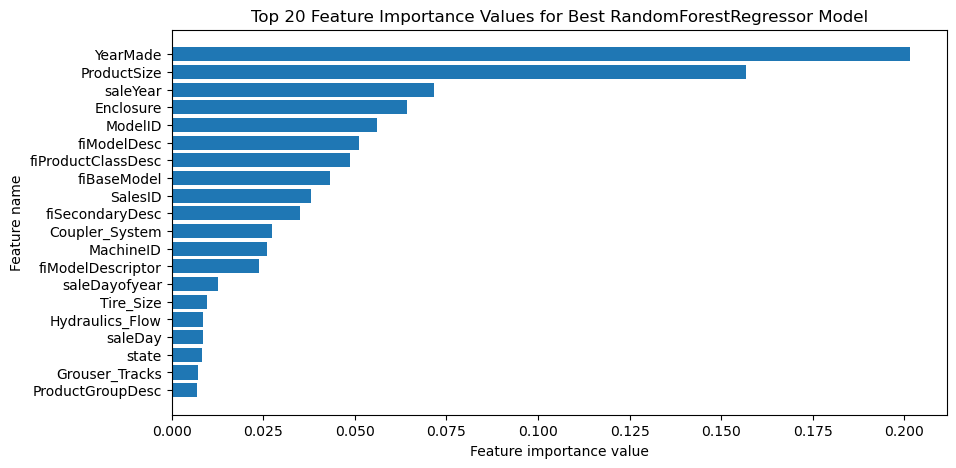

In [ ]:
# Plot the top feature importance values
top_n = 20
plt.figure(figsize=(10, 5))
plt.barh(y=feature_importance_df["feature_names"][:top_n], # Plot the top_n feature importance values
         width=feature_importance_df["feature_importance"][:top_n])
plt.title(f"Top {top_n} Feature Importance Values for Best RandomForestRegressor Model")
plt.xlabel("Feature importance value")
plt.ylabel("Feature name")
plt.gca().invert_yaxis();

In [ ]:
print(f"[INFO] Unique ProductSize values: {train_df['ProductSize'].unique()}")
print(f"[INFO] Unique Enclosure values: {train_df['Enclosure'].unique()}")

[INFO] Unique ProductSize values: ['Medium' nan 'Compact' 'Small' 'Large' 'Large / Medium' 'Mini']
[INFO] Unique Enclosure values: ['OROPS' 'EROPS' 'EROPS w AC' nan 'EROPS AC' 'NO ROPS'
 'None or Unspecified']


## 10. Final ML pipeline


### 10.1 using RandomForestRegressor

In [ ]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, root_mean_squared_log_error
from sklearn.preprocessing import OrdinalEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline


# Import and prepare data
train_df = pd.read_csv("data/bluebook-for-bulldozers/Train.csv",
                       parse_dates=["saledate"],
                       low_memory=False).sort_values(by="saledate", ascending=True)

valid_df = pd.read_csv("data/bluebook-for-bulldozers/Valid.csv",
                       parse_dates=["saledate"])

valid_solution = pd.read_csv("data/bluebook-for-bulldozers/ValidSolution.csv")
valid_df["SalePrice"] = valid_df["SalesID"].map(valid_solution.set_index("SalesID")["SalePrice"])
valid_df = valid_df.sort_values("saledate", ascending=True).reset_index(drop=True)

# Add datetime features
def add_datetime_features_to_df(df, date_column="saledate"):
    df = df.copy()
    df["saleYear"] = df[date_column].dt.year
    df["saleMonth"] = df[date_column].dt.month
    df["saleDay"] = df[date_column].dt.day
    df["saleDayofweek"] = df[date_column].dt.dayofweek
    df["saleDayofyear"] = df[date_column].dt.dayofyear
    return df.drop(date_column, axis=1)

# Apply datetime features
train_df = add_datetime_features_to_df(train_df)
valid_df = add_datetime_features_to_df(valid_df)

# Split data into features and labels
X_train = train_df.drop("SalePrice", axis=1)
y_train = train_df["SalePrice"]
X_valid = valid_df.drop("SalePrice", axis=1)
y_valid = valid_df["SalePrice"]

# Define feature types
numeric_features = [label for label, content in X_train.items()
                   if pd.api.types.is_numeric_dtype(content)]
categorical_features = [label for label, content in X_train.items()
                       if not pd.api.types.is_numeric_dtype(content)]

# Create preprocessing steps
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('string_converter', FunctionTransformer(lambda x: x.astype(str))), # convert values to string
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value',
                              unknown_value=np.nan,
                              encoded_missing_value=np.nan)),
])

# Create preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical_transforms', numeric_transformer, numeric_features),
        ('categorical_transforms', categorical_transformer, categorical_features)
    ])

# Create full pipeline
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=90,
        max_depth=None,
        min_samples_leaf=1,
        min_samples_split=5,
        max_features=0.5,
        n_jobs=-1,
        max_samples=None
    ))
])

# Function to evaluate the pipeline
def evaluate_pipeline(pipeline, X_train, y_train, X_valid, y_valid):
    # Make predictions
    train_preds = pipeline.predict(X_train)
    valid_preds = pipeline.predict(X_valid)

    # Calculate scores
    scores = {
        "Training MAE": mean_absolute_error(y_train, train_preds),
        "Valid MAE": mean_absolute_error(y_valid, valid_preds),
        "Training RMSLE": root_mean_squared_log_error(y_train, train_preds),
        "Valid RMSLE": root_mean_squared_log_error(y_valid, valid_preds),
        "Training R^2": pipeline.score(X_train, y_train),
        "Valid R^2": pipeline.score(X_valid, y_valid)
    }
    return scores

# Fit and evaluate pipeline
model_pipeline.fit(X_train, y_train)
pipeline_scores = evaluate_pipeline(model_pipeline, X_train, y_train, X_valid, y_valid)
print("\nPipeline Scores:")
pipeline_scores


Pipeline Scores:


{'Training MAE': 1952.919496310322,
 'Valid MAE': 5937.267793481814,
 'Training RMSLE': 0.1020410595786651,
 'Valid RMSLE': 0.24651624235131273,
 'Training R^2': 0.9810438200221746,
 'Valid R^2': 0.8821943701025667}

### 10.2 using HistGradientBoostingRegressor

In [ ]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, root_mean_squared_log_error
from sklearn.preprocessing import OrdinalEncoder, FunctionTransformer, StandardScaler
from sklearn.pipeline import Pipeline

# Import and prepare data
train_df = pd.read_csv("data/bluebook-for-bulldozers/Train.csv",
                       parse_dates=["saledate"],
                       low_memory=False).sort_values(by="saledate", ascending=True)

valid_df = pd.read_csv("data/bluebook-for-bulldozers/Valid.csv",
                       parse_dates=["saledate"])

valid_solution = pd.read_csv("data/bluebook-for-bulldozers/ValidSolution.csv")
valid_df["SalePrice"] = valid_df["SalesID"].map(valid_solution.set_index("SalesID")["SalePrice"])
valid_df = valid_df.sort_values("saledate", ascending=True).reset_index(drop=True)

# Add datetime features
def add_datetime_features_to_df(df, date_column="saledate"):
    df = df.copy()
    df["saleYear"] = df[date_column].dt.year
    df["saleMonth"] = df[date_column].dt.month
    df["saleDay"] = df[date_column].dt.day
    df["saleDayofweek"] = df[date_column].dt.dayofweek
    df["saleDayofyear"] = df[date_column].dt.dayofyear
    return df.drop(date_column, axis=1)

# Apply datetime features
train_df = add_datetime_features_to_df(train_df)
valid_df = add_datetime_features_to_df(valid_df)

# Split data into features and labels
X_train = train_df.drop("SalePrice", axis=1)
y_train = train_df["SalePrice"]
X_valid = valid_df.drop("SalePrice", axis=1)
y_valid = valid_df["SalePrice"]

# Define feature types
numeric_features = [label for label, content in X_train.items()
                   if pd.api.types.is_numeric_dtype(content)]
categorical_features = [label for label, content in X_train.items()
                       if not pd.api.types.is_numeric_dtype(content)]

# Create preprocessing steps for different types of values
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_transformer = Pipeline(steps=[
    ('string_converter', FunctionTransformer(lambda x: x.astype(str))), # convert values to string
    ('ordinal', OrdinalEncoder(categories='auto',
                               handle_unknown='use_encoded_value',
                               unknown_value=np.nan,
                               encoded_missing_value=np.nan)),
])

# Create preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical_transforms', numeric_transformer, numeric_features),
        ('categorical_transforms', categorical_transformer, categorical_features)
    ])

# Create full pipeline
model_pipeline_hist_gradient_boosting_regressor = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', HistGradientBoostingRegressor()) # Change model to HistGradientBoostingRegressor
])

# Function to evaluate the pipeline
def evaluate_pipeline(pipeline, X_train, y_train, X_valid, y_valid):
    # Make predictions
    train_preds = pipeline.predict(X_train)
    valid_preds = pipeline.predict(X_valid)

    # Calculate scores
    scores = {
        "Training MAE": mean_absolute_error(y_train, train_preds),
        "Valid MAE": mean_absolute_error(y_valid, valid_preds),
        "Training RMSLE": root_mean_squared_log_error(y_train, train_preds),
        "Valid RMSLE": root_mean_squared_log_error(y_valid, valid_preds),
        "Training R^2": pipeline.score(X_train, y_train),
        "Valid R^2": pipeline.score(X_valid, y_valid)
    }
    return scores

# Fit and evaluate pipeline
print(f"[INFO] Fitting HistGradientBoostingRegressor model with pipeline...")
model_pipeline_hist_gradient_boosting_regressor.fit(X_train, y_train)
print(f"[INFO] Evaluating HistGradientBoostingRegressor model with pipeline...")
pipeline_hist_scores = evaluate_pipeline(model_pipeline_hist_gradient_boosting_regressor, X_train, y_train, X_valid, y_valid)
print("\nPipeline HistGradientBoostingRegressor Scores:")
pipeline_hist_scores

[INFO] Fitting HistGradientBoostingRegressor model with pipeline...
[INFO] Evaluating HistGradientBoostingRegressor model with pipeline...

Pipeline HistGradientBoostingRegressor Scores:


{'Training MAE': 5642.1018064344435,
 'Valid MAE': 7286.482069518643,
 'Training RMSLE': 0.26944331748895295,
 'Valid RMSLE': 0.30419998907070267,
 'Training R^2': 0.8648619833622614,
 'Valid R^2': 0.8323865827929111}